In [1]:
#%matplotlib ipympl
%cd ..
import math
import torch as tn
import torchtt as tntt
import numpy as np
from src.qtt_interpolation.utils import *
from src.qtt_interpolation.qttnoise import *
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

/nfs/users/siddhartha.morales/TTinterpolation/QTT-polynomial-interpolation


/home/users/siddhartha.morales/TTinterpolation/QTT-polynomial-interpolation/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
depth = 10
octaves = 9
H = 1.1
mpsm = mid_point_1d(depth,octaves=octaves, nrank=5,var=1,eps=1e-12, H = H)

tensor([0.9239, 0.0413], dtype=torch.float64)


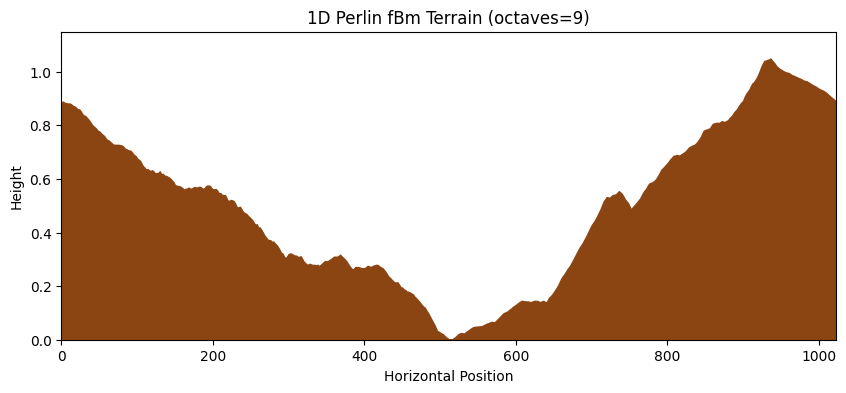

In [3]:
terrain_heights = mpsm.full().flatten()
terrain_heights -= terrain_heights.min()
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(2**depth)
ax.fill_between(x, terrain_heights, color='saddlebrown')
ax.set_ylim(0, terrain_heights.max()+.1)
ax.set_xlim(0, 2**depth -1)
ax.set_title(f"1D Perlin fBm Terrain (octaves={octaves})")
ax.set_xlabel("Horizontal Position")
ax.set_ylabel("Height")
plt.show()

In [440]:
def mid_point_2d(ncores,iscale=1,octaves=None, nrank=10,var=1,eps=1e-10, alpha=0.5,H = 1,amp = 1):

    if octaves==None:
        octaves = ncores
    elif octaves + iscale > ncores:
        octaves = ncores - iscale
    depth = ncores
    w = alpha**(H)
    r = nrank
    mpsm = 0
    for i in range(iscale,iscale + octaves+1):
        if  i == ncores :
            delta = tntt.kron(tntt.ones([2,2]*(i-1)),tntt.TT(tn.tensor([1,1,1,1],dtype=tn.float64),[2,2]) )
            noise = tntt.randn([2,2]*i,[1]+[r]*(2*i-1)+[1],var=var)
            noise = noise*delta
            mpsm += amp * noise
            #mpsm = (mpsm).round(eps)
        else:
            phi1 = tntt.TT(qtt_polynomial_cores([1,-1], depth-i))
            phi2 = tntt.TT(qtt_polynomial_cores([0,1], depth-i))
            ones = tntt.ones([2,2]*i)
            onesf = tntt.ones([2]*(depth-i))
            oneso = tntt.eye([2]*(depth-i))
            zones2 = zukron(onesf, onesf)
            Px = [tntt.kron(ones,zukron(phi1,onesf)),tntt.kron(ones,zukron(phi2,onesf))]
            Py = [tntt.kron(ones,zukron(onesf,phi1)),tntt.kron(ones,zukron(onesf,phi2))]
            # define shift matrix
            if i == 1:
                noise = tntt.TT(tn.randn(4, dtype=tn.float64),[2,2])
                
                noise = tntt.kron(noise,zones2)
                M = tntt.TT(tn.tensor([[0,1],[1,0]],dtype=tn.float64),[(2,2)])
                id = tntt.kron( tntt.eye([2]), oneso)
                S = tntt.kron( M, oneso)
                Sx = zukron(S,id)
                Sy = zukron(id,S)

                #interpolate x

                mpsm = noise * Px[0] + (Sx@noise) * Px[1]

                #interpolate y
                mpsm = mpsm * Py[0] + (Sy@mpsm) * Py[1]
                
            
            else:
                delta = tntt.kron(tntt.ones([2,2]*(i-1)),tntt.TT(tn.tensor([1,1,1,0],dtype=tn.float64),[2,2]) )
                noise = tntt.randn([2,2]*i,[1]+[r]*(2*i-1)+[1],var=var)
                noise = noise*delta
                S = tntt.kron(P_qtt( 2**i -1, i),oneso)
                id = tntt.kron( tntt.eye([2]*i), oneso)
                Sx = zukron(S,id)
                Sy = zukron(id,S)
                noise = tntt.kron(noise,zones2)

                #interpolate x
                level = noise * Px[0] + (Sx@noise) * Px[1]

                #interpolate y
                level = level * Py[0] + (Sy@level) * Py[1]
                
                mpsm += amp * level
        
        amp *= w
    mpsm = mpsm.round(eps)

    return mpsm

In [444]:
depth = 11
iscale= 2
octaves = depth - 1
H = 0.8
amp = 1
mpsm = mid_point_2d(depth,iscale=iscale,octaves=octaves, nrank=6,var=1,eps=1e-10, H = H)
terr = z_order_to_normal_torch(mpsm.full().flatten(),2**depth, 2**depth)
#terr /= terr.max()

In [445]:
mpsm

TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
R = [1, 2, 4, 8, 16, 32, 64, 114, 106, 95, 87, 76, 68, 57, 49, 38, 30, 21, 15, 8, 4, 2, 1]

Device: cpu, dtype: torch.float64
#entries 126006 compression 0.030042171478271484

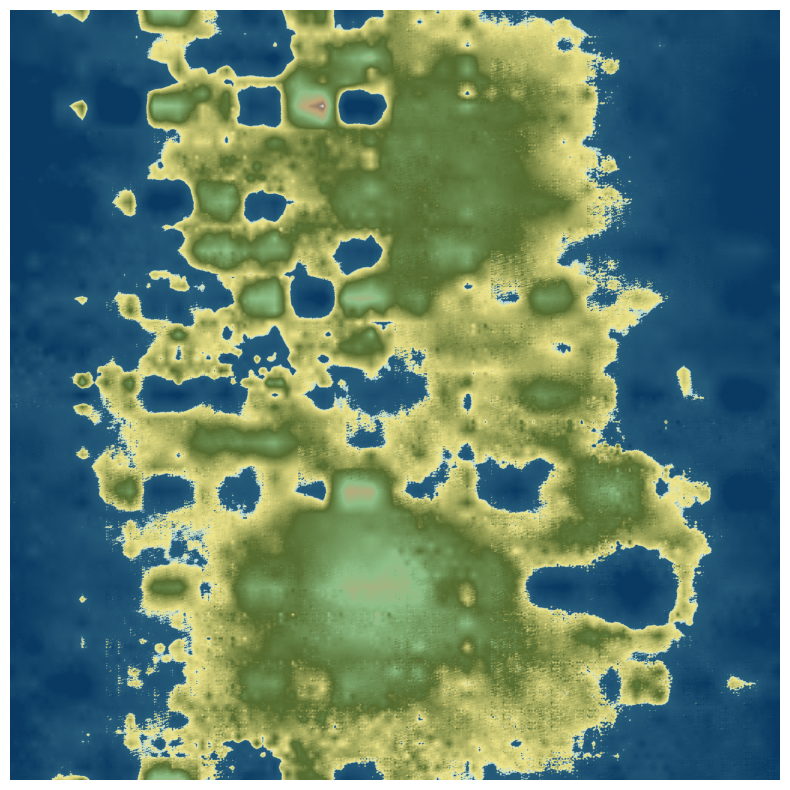

In [446]:
# — normalize heightmap to [0,1] —
terr = (terr - terr.min()) / (terr.max() - terr.min())
# USGS-style realistic terrain colormap
sea_level   = 0.5
land        = 1.0 - sea_level
deep_end    = sea_level * 0.6
shallow_end = sea_level
dune_end    = sea_level + land * 0.02
low_end     = sea_level + land * 0.20
mid_end     = sea_level + land * 0.50
high_end    = sea_level + land * 0.75
rock_end    = sea_level + land * 0.90
snow_end    = 1.0

colors = [
    (0.00,        '#0A3A62'),  # deep ocean
    (deep_end,    '#0A3A62'),
    (shallow_end, '#275C7A'),  # shallow ocean
    (sea_level,   '#A7D5ED'),  # coastal water
    (dune_end,    '#F0E68C'),  # sandy beach
    (low_end,     '#556B2F'),  # lowland grass
    (mid_end,     '#8EBF87'),  # rolling hills
    (high_end,    '#C2A679'),  # uplands
    (rock_end,    '#8B7765'),  # bare rock
    (snow_end,    '#FFFFFF'),  # snow caps
]
cmap = LinearSegmentedColormap.from_list('RealisticTerrain', colors)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(
    terr,
    cmap=cmap,
    origin='lower',
    extent=[0, 1, 0, 1]
)
ax.axis('off')
plt.tight_layout()
plt.show()


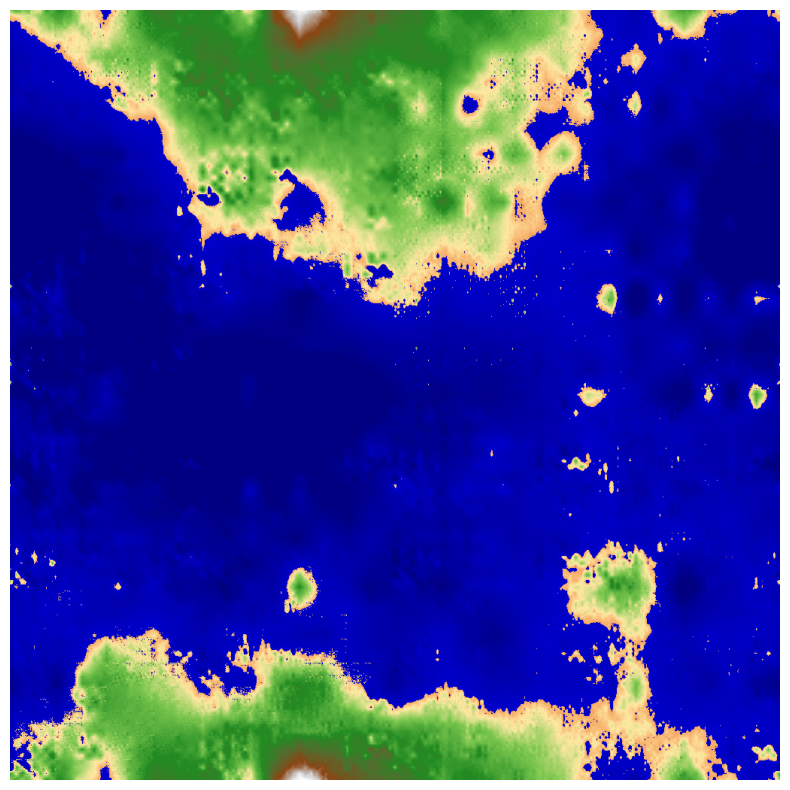

In [342]:
# — normalize heightmap to [0,1] —
terr = (terr - terr.min())/(terr.max() - terr.min())

# — user‐tweakable parameters —
sea_level        = 0.5   # waterline
deep_frac        = 0.6   # deep→shallow break (fraction of sea)
dune_frac        = 0.05  # tiny sand dune above beach
grass_low_frac   = 0.15  # first grass band
grass_high_frac  = 0.30  # second grass band
hill_frac        = 0.50  # foothills
rock_frac        = 0.70  # bare rock
peak_frac        = 0.90  # high-altitude scree

# — compute absolute positions on [0,1] —
sea   = sea_level
land  = 1.0 - sea_level

deep_end       = sea * deep_frac
shallow_end    = sea
dune_end       = sea + land * dune_frac
grass_low_end  = sea + land * grass_low_frac
grass_high_end = sea + land * grass_high_frac
hill_end       = sea + land * hill_frac
rock_end       = sea + land * rock_frac
peak_end       = sea + land * peak_frac
snow_end       = 1.0

# — assemble (position, color) list —
colors = [
    (0.00, deep_color   := '#000080'),  # deep ocean
    (deep_end, deep_color),
    (shallow_end, '#0000cd'),           # shallow ocean
    (sea, '#f4a460'),                   # beach / sand
    (dune_end, '#ffe9a3'),              # sand dunes
    (grass_low_end, '#7ec850'),         # light grass
    (grass_high_end, '#228b22'),        # dark grass
    (hill_end, '#556b2f'),              # foothills
    (rock_end, '#8b4513'),              # bare rock
    (peak_end, '#cccccc'),              # scree / high rock
    (snow_end, '#ffffff'),              # snow caps
]

cmap = LinearSegmentedColormap.from_list('VeryDetailedTerrain', colors)

# — plot with no axes, no interpolation —
fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(
    terr,
    cmap=cmap,
    origin='lower',
    extent=[0,1,0,1],
)
ax.axis('off')
plt.tight_layout()
plt.show()

## Sounds

In [1]:
import math
import random
import numpy as np
import scipy.signal as signal
import scipy.io.wavfile as wavfile

# ─── 1D Perlin Noise (single octave) ───────────────────────────────
_perm = list(range(256))
random.seed(0)
random.shuffle(_perm)
_perm += _perm

def fade(t):
    return t * t * t * (t * (t * 6 - 15) + 10)

def lerp(a, b, t):
    return a + t * (b - a)

def grad(hash_val, x):
    return (1 if (hash_val & 1) == 0 else -1) * x

def perlin1d(x):
    x0 = math.floor(x)
    x1 = x0 + 1
    dx0 = x - x0
    dx1 = dx0 - 1.0
    h0 = _perm[x0 & 255]
    h1 = _perm[x1 & 255]
    dot0 = grad(h0, dx0)
    dot1 = grad(h1, dx1)
    u = fade(dx0)
    return lerp(dot0, dot1, u)

# ─── Fractal Brownian Motion wrapper ────────────────────────────────
def fbm1d(x, octaves=6, persistence=0.5, lacunarity=2.0):
    total = 0.0
    amplitude = 1.0
    frequency = 1.0
    max_amp = 0.0
    for _ in range(octaves):
        total += perlin1d(x * frequency) * amplitude
        max_amp += amplitude
        amplitude *= persistence
        frequency *= lacunarity
    return total / max_amp  # normalized to [-1,1]

# ─── Wind Sound Generation ───────────────────────────────────────────
fs = 44100              # sample rate (Hz)
duration = 30.0         # now 30 seconds long
num_samples = int(fs * duration)

# fBm parameters
noise_scale = 20000.0   # controls “speed” of the wind fluctuations
octaves = 6
persistence = 0.5
lacunarity = 2.0

# allocate buffer
wind_raw = np.zeros(num_samples, dtype=np.float32)

# fill with Perlin-fBm samples
for n in range(num_samples):
    wind_raw[n] = fbm1d(n / noise_scale, octaves, persistence, lacunarity)

# ─── Low-pass filter to smooth out high frequencies ────────────────
b, a = signal.butter(4, 3000/(fs/2), btype='low')
wind_filtered = signal.filtfilt(b, a, wind_raw)

# normalize to [-1, +1]
wind_filtered -= wind_filtered.min()
wind_filtered /= wind_filtered.max()
wind_filtered = wind_filtered * 2.0 - 1.0

# convert to 16-bit PCM
wind_int16 = np.int16(wind_filtered * 32767)

# write WAV file
out_path = "./data/perlin_wind_30s.wav"
wavfile.write(out_path, fs, wind_int16)

print(f"30 s wind sound written to: {out_path}")


30 s wind sound written to: ./data/perlin_wind_30s.wav
